Name: Navpreet Kloy

Monday Lab Partner: Oscar Ramos

Wednesday Lab Partner: Oscar Ramos

Breast Cancer Wisconsin (Diagnostic) Data Set
https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

In [ ]:
#Import Libraries needed for the program
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
#Load the obesity dataset from the CSV file
df=pd.read_csv("data.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [ ]:
#remove columns
df.drop(columns=['id'], inplace=True, errors='ignore')
df.drop(columns=['Unnamed: 32'], inplace=True, errors='ignore')

In [ ]:
#convert categorical columns into numbers (same style, simple)
le_diagnosis=LabelEncoder()
df['diagnosis']=le_diagnosis.fit_transform(df['diagnosis'])
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
#Separate the dataset into features (X) and target (y)
X=df.drop('diagnosis', axis=1)
y=df['diagnosis']

print(f"Number of features after cleaning:{X.shape[1]}")
print(f"Classes in dataset: Class 0:{sum(y==0)}, Class 1: {sum(y==1)}")

Number of features after cleaning:30
Classes in dataset: Class 0:357, Class 1: 212


In [ ]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test=train_test_split(
    X,y, test_size=0.3, random_state=42
)

In [ ]:
#Scale the feature data
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
#Linear Kernel
print("\n1. LINEAR Kernel:")
svm_linear=SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)

y_pred_linear=svm_linear.predict(X_test)
accuracy_linear=accuracy_score(y_test, y_pred_linear)
print(f"Linear Accuracy: {accuracy_linear*100:.2f}%")


1. LINEAR Kernel:
Linear Accuracy: 97.66%


In [ ]:
#RBF Kernel
print("\n2.RBF Kernel:")
svm_rbf=SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train, y_train)

y_pred_rbf=svm_rbf.predict(X_test)
accuracy_rbf=accuracy_score(y_test,y_pred_rbf)
print(f"RBF Accuracy: {accuracy_rbf*100:2f}%")


2.RBF Kernel:
RBF Accuracy: 97.660819%


In [ ]:
#Polynomial Kernel
print("\n3. POLYNOMIAL Kernel:")
svm_poly=SVC(kernel='poly',degree=3,C=1.0,gamma='scale')
svm_poly.fit(X_train, y_train)

y_pred_poly=svm_poly.predict(X_test)
accuracy_poly=accuracy_score(y_test, y_pred_poly)
print(f"Polynomial Accuracy: {accuracy_poly*100:.2f}%")


3. POLYNOMIAL Kernel:
Polynomial Accuracy: 89.47%


In [ ]:
#Result summary
print("\n"+"="*60)
print("RESULTS SUMMARY")
print("="*60)
print(f"Linear: {accuracy_linear*100:.2f}%")
print(f"RBF: {accuracy_rbf*100:.2f}%")
print(f"Polynomial: {accuracy_poly*100:.2f}%")

accuracies={
    'Linear':accuracy_linear,
    'RBF':accuracy_rbf,
    'Polynomial':accuracy_poly
}

best_kernel=max(accuracies, key=accuracies.get)
print(f"\nBest Kernel: {best_kernel}")


RESULTS SUMMARY
Linear: 97.66%
RBF: 97.66%
Polynomial: 89.47%

Best Kernel: Linear


In [ ]:
#Detailed report for best kernel
print("\n"+"="*60)
print(f"DETAILED CLASSIFICATION REPORT ({best_kernel}Kernel)")
print("="*60)

if best_kernel == 'Linear':
  print(classification_report(y_test,y_pred_linear,target_names=['Benign','Malignant']))
elif best_kernel == 'RBF':
    print(classification_report(y_test,y_pred_rbf,target_names=['Benign','Malignant']))
else:
    print(classification_report(y_test,y_pred_poly,target_names=['Benign','Malignant']))


DETAILED CLASSIFICATION REPORT (LinearKernel)
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98       108
   Malignant       0.97      0.97      0.97        63

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171




Generating visualization...


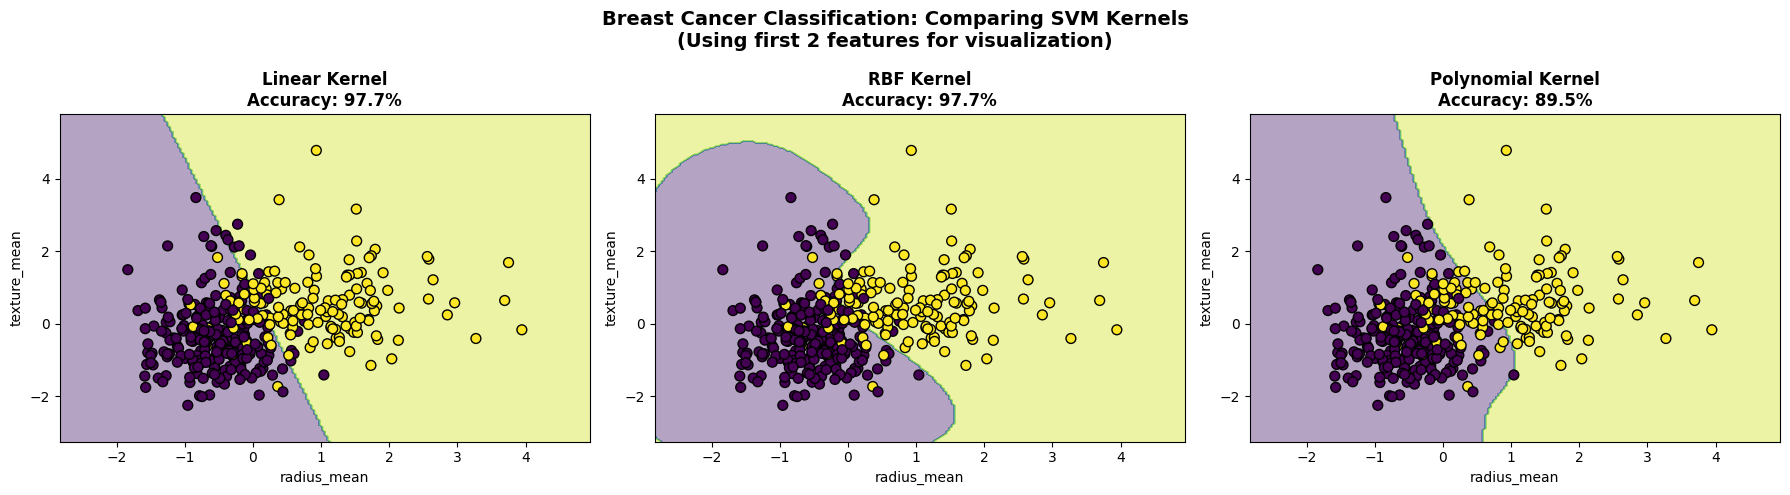

In [ ]:
#Simple Visualization
print("\nGenerating visualization...")

# For visualization, we'll use only the first 2 features
X_2d = X.iloc[:, :2].values

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.3, random_state=42
)

# Scale the 2D data
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

kernels = [
    ('linear', 'Linear', accuracy_linear),
    ('rbf', 'RBF', accuracy_rbf),
    ('poly', 'Polynomial', accuracy_poly)
]

# Create mesh grid
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1
y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Plot each kernel
for idx, (kernel_name, kernel_label, accuracy) in enumerate(kernels):
    if kernel_name == 'poly':
        model = SVC(kernel=kernel_name, degree=3, C=1.0, gamma='scale')
    else:
        model = SVC(kernel=kernel_name, C=1.0, gamma='scale')

    model.fit(X_train_2d_scaled, y_train_2d)

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[idx].contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    axes[idx].scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1],
                      c=y_train_2d, edgecolors='k', cmap='viridis', s=50)

    axes[idx].set_title(f'{kernel_label} Kernel\nAccuracy: {accuracy*100:.1f}%',
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(X.columns[0], fontsize=10)
    axes[idx].set_ylabel(X.columns[1], fontsize=10)

plt.suptitle('Breast Cancer Classification: Comparing SVM Kernels\n(Using first 2 features for visualization)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
#Explanation
print("\n" + "="*70)
print("EXPLANATION FOR EVERYONE:")
print("="*70)
print("This program demonstrates how Support Vector Machines can classify")
print("breast cancer cases into two categories based on medical measurements.")
print("We tested three different approaches (kernels):")
print("  1. LINEAR - draws straight lines to separate classes")
print("  2. RBF - draws circular/curved boundaries")
print("  3. POLYNOMIAL - draws polynomial curves")
print()
print("Feature scaling is important because the measurements have different ranges.")
print("Without scaling, features with larger numbers could dominate the model.")
print("="*70)


EXPLANATION FOR EVERYONE:
This program demonstrates how Support Vector Machines can classify
breast cancer cases into two categories based on medical measurements.
We tested three different approaches (kernels):
  1. LINEAR - draws straight lines to separate classes
  2. RBF - draws circular/curved boundaries
  3. POLYNOMIAL - draws polynomial curves

Feature scaling is important because the measurements have different ranges.
Without scaling, features with larger numbers could dominate the model.


SUMMARY:
This project applied Support Vector Machine (SVM) models to classify breast cancer data into benign and malignant cases. After cleaning the dataset and encoding the diagnosis column, the data was scaled to ensure all features contributed equally. Three different SVM kernels-linear, RBF, and polynomial-were tested and compared. The results showed that both the linear and RBF kernels achieved the highest accuracy, while the polynomial kernel performed slightly lower. Visualizations of the decision boundaries helped illustrate how each kernel separates the data. Overall, the project demonstrates that SVM is an effective method for medical classification tasks and highlights the importance of feature scaling and kernel selection.